
#Perceptrón Multicapa (MLP) sobre datos bancarios reales en Google Colab




## Preparación del entorno en Google Colab



In [ ]:
!pip -q install ucimlrepo seaborn


## 1. Fundamentos matemáticos de una Red Neuronal con Backpropagation

Una red neuronal multicapa implementa una composición de funciones afines y funciones no lineales. Si el vector de entrada es




### 1.1 Forward Pass

El **forward pass** es el proceso mediante el cual los datos de entrada atraviesan la red desde la capa de entrada hasta la salida.


### 1.2 Backward Pass

El **backward pass** o **backpropagation** calcula el gradiente de la función de pérdida respecto a todos los parámetros de la red.




## 2. Setting up the Neural Network
### Arquitectura, parámetros e imagen conceptual

Emplearemos `MLPClassifier` de scikit-learn para crear un MLP con la siguiente arquitectura:

$$
17 \rightarrow 13 \rightarrow 10 \rightarrow 2 \rightarrow 1
$$

donde:
- 17 = número de variables de entrada después del preprocesamiento,
- 13, 10 y 2 = capas ocultas,
- 1 = salida binaria.

### Parámetros importantes
- `hidden_layer_sizes=(13,10,2)`: define la arquitectura oculta.
- `activation='relu'` o la predeterminada de sklearn.
- `solver='adam'`: optimización adaptativa.
- `max_iter=1000`: máximo de iteraciones de entrenamiento.
- `random_state`: para reproducibilidad.

A continuación dibujamos una **imagen conceptual** simple de la arquitectura.


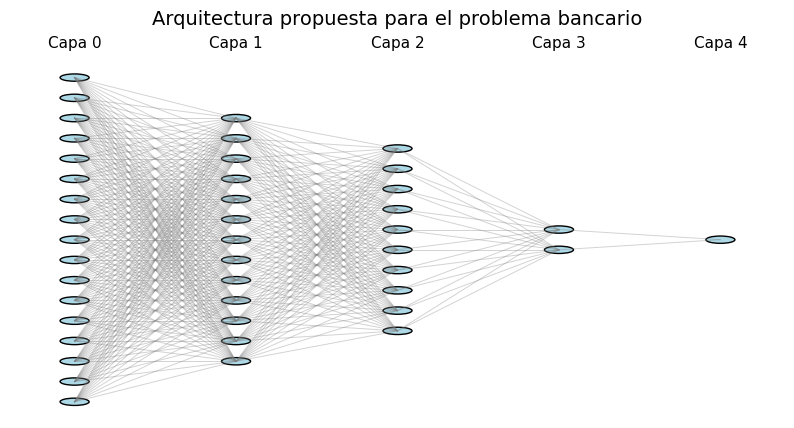

In [ ]:

import matplotlib.pyplot as plt

def draw_mlp_architecture(layer_sizes, title="Arquitectura del MLP"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")

    x_spacing = 2.0
    max_neurons = max(layer_sizes)

    for layer_idx, n_neurons in enumerate(layer_sizes):
        y_offset = (max_neurons - n_neurons) / 2
        for neuron_idx in range(n_neurons):
            x = layer_idx * x_spacing
            y = neuron_idx + y_offset
            circle = plt.Circle((x, y), 0.18, color="lightblue", ec="black")
            ax.add_patch(circle)

            if layer_idx < len(layer_sizes) - 1:
                next_n = layer_sizes[layer_idx + 1]
                next_y_offset = (max_neurons - next_n) / 2
                for next_idx in range(next_n):
                    x2 = (layer_idx + 1) * x_spacing
                    y2 = next_idx + next_y_offset
                    ax.plot([x, x2], [y, y2], color="gray", alpha=0.35, linewidth=0.7)

        ax.text(layer_idx * x_spacing, max_neurons + 0.5, f"Capa {layer_idx}", ha="center", fontsize=11)

    ax.set_xlim(-0.8, x_spacing * (len(layer_sizes)-1) + 0.8)
    ax.set_ylim(-0.8, max_neurons + 1.2)
    ax.set_title(title, fontsize=14)
    plt.show()

draw_mlp_architecture([17, 13, 10, 2, 1], title="Arquitectura propuesta para el problema bancario")


## 3. Pipeline


### 3.1 Carga de datos

Dataset de campañas bancarias portuguesas. El objetivo es predecir si un cliente se suscribe o no a un depósito a plazo.

Se emplea el dataset `bank-additional-full.csv`.

In [ ]:

import pandas as pd

csv_url = "https://raw.githubusercontent.com/HegdeChaitra/Bank-Marketing-Campaign-Analysis/master/bank-additional-full.csv"

df = pd.read_csv(csv_url, sep=';')
print(df.shape)
df.head()


(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



### 4.2 Preparación y codificación

Se emplea **LabelEncoder** para variables categóricas seleccionadas y luego elimina columnas originales para conservar sus códigos numéricos.


In [ ]:

from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

df['job_code'] = LE.fit_transform(df['job'])
df['marital_code'] = LE.fit_transform(df['marital'])
df['education_code'] = LE.fit_transform(df['education'])
df['housing_code'] = LE.fit_transform(df['housing'])
df['loan_code'] = LE.fit_transform(df['loan'])
df['contact_code'] = LE.fit_transform(df['contact'])
df['poutcome_code'] = LE.fit_transform(df['poutcome'])
df['subscribed'] = LE.fit_transform(df['y'])

df = df.drop(
    ['job','marital','education','housing','loan','contact',
     'poutcome','y','day_of_week','month','default'],
    axis=1
)

print(df.columns.tolist())
print("Dimensión final del DataFrame:", df.shape)
df.head()


['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_code', 'marital_code', 'education_code', 'housing_code', 'loan_code', 'contact_code', 'poutcome_code', 'subscribed']
Dimensión final del DataFrame: (41188, 18)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_code,marital_code,education_code,housing_code,loan_code,contact_code,poutcome_code,subscribed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,3,1,0,0,0,1,1,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,7,1,3,0,0,1,1,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,7,1,3,2,0,1,1,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,1,1,0,0,1,1,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,7,1,3,0,2,1,1,0



### 4.3 Model Selection

#### ¿Por qué usar una red neuronal?

Formalmente, una red neuronal multicapa es una buena opción cuando:

1. el problema es **de clasificación binaria**,
2. se sospecha que la frontera de decisión es **no lineal**,


#### Relación con el problema bancario

El problema bancario también es binario:
- `subscribed = 1`
- `subscribed = 0`

y es razonable asumir que depende de relaciones no lineales entre:
- duración de llamada,
- campaña,
- contactos previos,
- tipo de empleo,
- nivel educativo,
- tipo de contacto,
- etc.

Por eso un MLP es un candidato formalmente adecuado.



### 4.4 Train/Test Split y escalamiento

Las redes neuronales suelen beneficiarse mucho del escalamiento de variables.  
Usaremos `StandardScaler`, exactamente como en el artículo.


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('subscribed', axis=1)
y = df['subscribed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (30891, 17)
X_test: (10297, 17)


### 4.5 Model Training

In [ ]:

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(13, 10, 2),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
print("Entrenamiento completado.")


Entrenamiento completado.


### 4.6 Validación del modelo

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

predictions = mlp.predict(X_test_scaled)

print("Confusion matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification report:")
print(classification_report(y_test, predictions))

acc = accuracy_score(y_test, predictions)
print("\nAccuracy:", acc)


Confusion matrix:
[[8830  307]
 [ 569  591]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      9137
           1       0.66      0.51      0.57      1160

    accuracy                           0.91     10297
   macro avg       0.80      0.74      0.76     10297
weighted avg       0.91      0.91      0.91     10297


Accuracy: 0.9149266776731086



### 4.7 Prediction

A continuación construimos una función para predecir un solo patrón.  
La función recibe un diccionario con las 17 features del modelo y devuelve:

- clase predicha,
- probabilidad de suscripción.


In [ ]:

def predict_single(sample_dict, model=mlp, scaler=scaler, feature_names=X.columns.tolist()):
    sample_df = pd.DataFrame([sample_dict])
    sample_df = sample_df[feature_names]
    sample_scaled = scaler.transform(sample_df)
    pred = int(model.predict(sample_scaled)[0])
    prob = float(model.predict_proba(sample_scaled)[0][1])
    return pred, prob


### 4.8 Ejemplo de predicción de un cliente

In [ ]:

sample_customer = {
    'age': 35,
    'duration': 180,
    'campaign': 1,
    'pdays': 999,
    'previous': 0,
    'emp.var.rate': -1.8,
    'cons.price.idx': 92.893,
    'cons.conf.idx': -46.2,
    'euribor3m': 1.313,
    'nr.employed': 5099.1,
    'job_code': 3,
    'marital_code': 1,
    'education_code': 2,
    'housing_code': 1,
    'loan_code': 0,
    'contact_code': 0,
    'poutcome_code': 1
}

pred, prob = predict_single(sample_customer)

print("Clase predicha:", pred)
print("Probabilidad de suscripción:", round(prob, 4))
if pred == 1:
    print("Interpretación: el cliente sí se suscribe.")
else:
    print("Interpretación: el cliente no se suscribe.")


Clase predicha: 0
Probabilidad de suscripción: 0.0112
Interpretación: el cliente no se suscribe.
